## Importing Files and Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

In [16]:
import pandas as pd

# Define the single Excel workbook name
file_name = "Google_SC_Interview_Dataset.xlsx"

# Load each tab directly into memory using pd.read_excel
parts_master       = pd.read_excel(file_name, sheet_name="Parts_Master")
demand_forecast    = pd.read_excel(file_name, sheet_name="Demand_Forecast")
inventory_coverage = pd.read_excel(file_name, sheet_name="Inventory_Coverage")
purchase_orders    = pd.read_excel(file_name, sheet_name="Purchase_Orders")
npi_tracker        = pd.read_excel(file_name, sheet_name="NPI_Program_Tracker")
supplier_scorecard = pd.read_excel(file_name, sheet_name="Supplier_Scorecard")

print("All 6 sheets loaded successfully!")

All 6 sheets loaded successfully!


In [23]:
print("=== SUCCESS: ALL 6 TABS LOADED ===")
print(f"Parts Master:        {parts_master.shape[0]} rows, {parts_master.shape[1]} columns")
print(f"Demand Forecast:     {demand_forecast.shape[0]} rows, {demand_forecast.shape[1]} columns")
print(f"Inventory Coverage:  {inventory_coverage.shape[0]} rows, {inventory_coverage.shape[1]} columns")
print(f"Purchase Orders:     {purchase_orders.shape[0]} rows, {purchase_orders.shape[1]} columns")
print(f"NPI Tracker:         {npi_tracker.shape[0]} rows, {npi_tracker.shape[1]} columns")
print(f"Supplier Scorecard:  {supplier_scorecard.shape[0]} rows, {supplier_scorecard.shape[1]} columns")


=== SUCCESS: ALL 6 TABS LOADED ===
Parts Master:        20 rows, 7 columns
Demand Forecast:     1560 rows, 7 columns
Inventory Coverage:  80 rows, 11 columns
Purchase Orders:     350 rows, 15 columns
NPI Tracker:         120 rows, 9 columns
Supplier Scorecard:  16 rows, 9 columns


## Date Normalization & Boolean Inferences

In [26]:
# 1. Clean boolean string variations in Parts Master ('True'/'False' or 1/0 to actual Booleans)
parts_master['Multi_Source'] = parts_master['Multi_Source'].astype(str).str.strip().str.upper().map({
    'TRUE': True, '1': True, 'FALSE': False, '0': False
})

# 2. Standardize date columns across all datasets to Pandas Datetime format
purchase_orders['PO_Date'] = pd.to_datetime(purchase_orders['PO_Date'])
purchase_orders['Need_By_Date'] = pd.to_datetime(purchase_orders['Need_By_Date'])
purchase_orders['Expected_Date'] = pd.to_datetime(purchase_orders['Expected_Date'])

npi_tracker['Planned_Date'] = pd.to_datetime(npi_tracker['Planned_Date'])
npi_tracker['Actual_Date'] = pd.to_datetime(npi_tracker['Actual_Date'])

demand_forecast['Week'] = pd.to_datetime(demand_forecast['Week'])

print("Data cleaning and type standardization complete!")

Data cleaning and type standardization complete!


### Visualizing Sourcing Vulnerabilities (SPOFs)

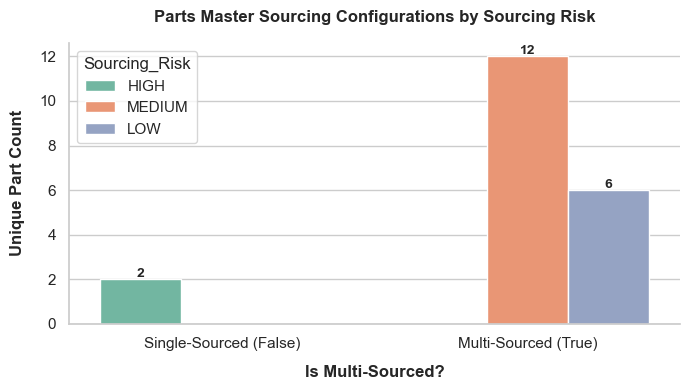

In [33]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=parts_master, 
    x='Multi_Source', 
    hue='Sourcing_Risk', 
    palette='Set2'
)

plt.title("Parts Master Sourcing Configurations by Sourcing Risk", fontsize=12, pad=15, fontweight='bold')
plt.xlabel("Is Multi-Sourced?", fontweight='bold', labelpad=10)
plt.ylabel("Unique Part Count", fontweight='bold', labelpad=10)
plt.xticks([0, 1], ['Single-Sourced (False)', 'Multi-Sourced (True)'])
sns.despine()

# Annotate values on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height() + 0.1), 
                    ha='center', va='baseline', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Relational Merges, Cohort Risk & Time-Series Plunges

#### Re-creating the "XIO Depletion Story" via Inventory Modeling

In [40]:
# Combine inventory coverage with parts master metadata
inventory_risk_df = pd.merge(
    inventory_coverage,
    parts_master[['Part_ID', 'Multi_Source', 'Lead_Time_Weeks', 'Unit_Cost_USD']],
    on='Part_ID',
    how='inner'
)

# Define logical inventory parameters
conditions = [
    (inventory_risk_df['Coverage_Weeks'] <= 4) & (inventory_risk_df['Multi_Source'] == False),
    (inventory_risk_df['Coverage_Weeks'] <= 6) & (inventory_risk_df['Multi_Source'] == True),
    (inventory_risk_df['Coverage_Weeks'] <= inventory_risk_df['Reorder_Point_Wks'])
]

choices = [
    'CRITICAL STOCKOUT RISK (Single Source)',
    'HIGH RISK (Low Multi-Source Stock)',
    'REORDER TRIGGERED'
]

# Create our alert column
inventory_risk_df['Fulfillment_Alert'] = np.select(conditions, choices, default='Healthy')

# Filter for active risk alerts
critical_cohort = inventory_risk_df[inventory_risk_df['Fulfillment_Alert'] != 'Healthy']

print("=== CRITICAL REGIONAL STOCK CONSTRAINTS ===")
display(critical_cohort[['Region', 'Part_ID', 'Part_Name', 'Supplier', 'Coverage_Weeks', 'Fulfillment_Alert']].head(8))

=== CRITICAL REGIONAL STOCK CONSTRAINTS ===


,Region,Part_ID,Part_Name,Supplier,Coverage_Weeks,Fulfillment_Alert
0,NAM,P1000,GPU,NVIDIA,15.3,REORDER TRIGGERED
1,EMEA,P1000,GPU,NVIDIA,4.2,HIGH RISK (Low Multi-Source Stock)
2,APJ,P1000,GPU,NVIDIA,14.6,REORDER TRIGGERED
3,BRH,P1000,GPU,NVIDIA,11.8,REORDER TRIGGERED
4,NAM,P1001,GPU,AMD,5.6,HIGH RISK (Low Multi-Source Stock)
5,EMEA,P1001,GPU,AMD,8.6,REORDER TRIGGERED
6,APJ,P1001,GPU,AMD,10.5,REORDER TRIGGERED
7,BRH,P1001,GPU,AMD,9.2,REORDER TRIGGERED


### Transactional PO Lead-Time Deviation & Capital-at-Risk

In [43]:
# Calculate delay metrics for open and delayed orders
purchase_orders['Lead_Time_Deviation'] = (purchase_orders['Expected_Date'] - purchase_orders['Need_By_Date']).dt.days

# Classify PO delivery performance
purchase_orders['Delivery_Class'] = np.where(
    purchase_orders['Lead_Time_Deviation'] > 0, 
    'Delayed', 
    'On-Time'
)

# Isolate delayed capital per row first to prevent index mismatch bugs
purchase_orders['Delayed_Capital_USD'] = np.where(
    purchase_orders['Status'] == 'Delayed', 
    purchase_orders['Total_Value_USD'], 
    0
)

# Group POs by supplier and calculate aggregate performance and financial impact
po_summary = purchase_orders.groupby('Supplier').agg(
    Total_POs_Placed=('PO_Number', 'count'),
    Delayed_POs=('Delivery_Class', lambda x: (x == 'Delayed').sum()),
    Avg_Days_Late=('Days_Late', 'mean'),
    Delayed_Capital_USD=('Delayed_Capital_USD', 'sum')
).reset_index()

# Calculate OTD %
po_summary['OTD_Percentage'] = round((1 - (po_summary['Delayed_POs'] / po_summary['Total_POs_Placed'])) * 100, 1)

# Sort by delayed capital descending
po_summary = po_summary.sort_values(by='Delayed_Capital_USD', ascending=False)

print("=== SUPPLIER DELIVERY PERFORMANCE & CAPITAL-AT-RISK ===")
display(po_summary)

=== SUPPLIER DELIVERY PERFORMANCE & CAPITAL-AT-RISK ===


,Supplier,Total_POs_Placed,Delayed_POs,Avg_Days_Late,Delayed_Capital_USD,OTD_Percentage
12,NVIDIA,13,9,7.615385,3041472.00,30.8
0,AMD,14,8,3.500000,2793600.00,42.9
4,Broadcom,35,21,4.400000,507215.20,40.0
10,Micron,33,22,3.272727,499244.20,33.3
9,Marvell,23,12,6.565217,324159.00,47.8
8,Kioxia,13,9,4.000000,271694.40,30.8
14,Samsung,31,18,4.000000,249622.20,41.9
7,Foxconn,44,25,2.772727,234592.60,43.2
13,SK Hynix,26,17,5.153846,150822.00,34.6
6,Flextronics,21,12,1.523810,141814.00,42.9


### Visualizing the Weeks 20–24 Demand Shock

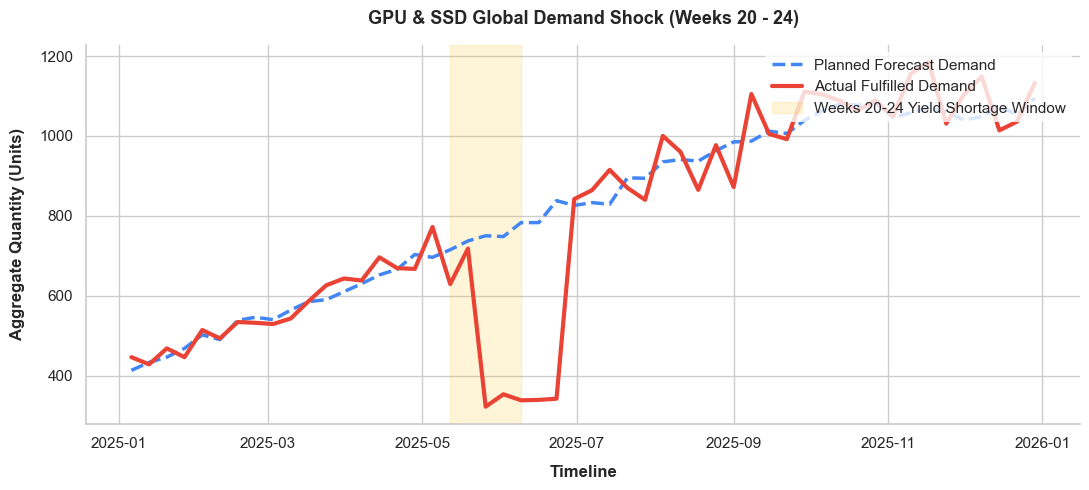

In [46]:
# Convert weeks to integers for clean trend analysis
demand_forecast['Week_Num'] = demand_forecast['Week'].dt.isocalendar().week

# Group the demand forecast by week to see the global trend
weekly_trend = demand_forecast[demand_forecast['Part_Name'].isin(['GPU', 'SSD'])].groupby('Week').agg(
    Forecast=('Forecast_Qty', 'sum'),
    Actual=('Actual_Demand', 'sum')
).reset_index()

plt.figure(figsize=(11, 5))
plt.plot(weekly_trend['Week'], weekly_trend['Forecast'], label='Planned Forecast Demand', color='#4285F4', linewidth=2.5, linestyle='--')
plt.plot(weekly_trend['Week'], weekly_trend['Actual'], label='Actual Fulfilled Demand', color='#EA4335', linewidth=3)

# Find start and end dates for week 20 and week 24
start_date = demand_forecast[demand_forecast['Week_Num'] == 20]['Week'].min()
end_date = demand_forecast[demand_forecast['Week_Num'] == 24]['Week'].max()
plt.axvspan(start_date, end_date, color='#FBBC05', alpha=0.15, label='Weeks 20-24 Yield Shortage Window')

plt.title("GPU & SSD Global Demand Shock (Weeks 20 - 24)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Timeline", fontweight='bold', labelpad=10)
plt.ylabel("Aggregate Quantity (Units)", fontweight='bold', labelpad=10)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
sns.despine()
plt.tight_layout()
plt.show()

## Cross-Functional Diagnostics & Unified Executive QBR Dashboard

### NPI Launch Schedule Variance & Delayed PO Correlation

In [51]:
# 1. Calculate Schedule Variance for NPI milestones (Actual Date minus Planned Date)
npi_tracker['Schedule_Variance_Days'] = (npi_tracker['Actual_Date'] - npi_tracker['Planned_Date']).dt.days

# Force numeric dtypes on Days_Variance and handle nulls
npi_tracker['Days_Variance'] = pd.to_numeric(npi_tracker['Days_Variance'], errors='coerce').fillna(0)
npi_tracker['Schedule_Variance_Days'] = npi_tracker['Schedule_Variance_Days'].fillna(npi_tracker['Days_Variance'])

# 2. Isolate NPI programs that are flagged as 'At Risk'
at_risk_programs = npi_tracker[npi_tracker['Status'] == 'At Risk'][['Program', 'Region', 'Milestone', 'Schedule_Variance_Days']]

# 3. Combine with demand forecast to identify which components belong to each program
npi_demand_map = pd.merge(
    at_risk_programs, 
    demand_forecast[['Program', 'Part_Name']].drop_duplicates(), 
    on='Program'
)

# 4. Map these components to physical Part IDs in our catalog
npi_part_map = pd.merge(
    npi_demand_map, 
    parts_master[['Part_ID', 'Part_Name']], 
    on='Part_Name'
)

# 5. Merge with open, delayed POs in the EXACT same region as the NPI launch
npi_logistics_impact = pd.merge(
    npi_part_map,
    purchase_orders[purchase_orders['Status'] == 'Delayed'][['Part_ID', 'Region', 'PO_Number', 'Supplier', 'Days_Late', 'Total_Value_USD']],
    on=['Part_ID', 'Region'],
    how='left'  # Ensure NPI milestones are visible even if a delayed PO is in a different hub
)

print("=== CROSS-FUNCTIONAL DIAGNOSTIC: NPI MILESTONE DELAYS VS. LATE PO COHORT ===")
display(npi_logistics_impact.sort_values(by='Schedule_Variance_Days', ascending=False))


=== CROSS-FUNCTIONAL DIAGNOSTIC: NPI MILESTONE DELAYS VS. LATE PO COHORT ===


,Program,Region,Milestone,Schedule_Variance_Days,Part_Name,Part_ID,PO_Number,Supplier,Days_Late,Total_Value_USD
0,Nutanix XC 17G,NAM,RTS / Launch,0.0,GPU,P1000,PO-10349,NVIDIA,23.0,190464.00
251,Heartbeat City Wave2,EMEA,RTS / Launch,0.0,Chassis,P1010,NaN,NaN,NaN,NaN
249,Heartbeat City Wave2,EMEA,RTS / Launch,0.0,DIMM,P1008,PO-10106,Micron,7.0,11552.00
248,Heartbeat City Wave2,EMEA,RTS / Launch,0.0,DIMM,P1008,PO-10072,Micron,26.0,20396.50
247,Heartbeat City Wave2,EMEA,RTS / Launch,0.0,DIMM,P1007,PO-10177,SK Hynix,21.0,34014.75
...,...,...,...,...,...,...,...,...,...,...
120,Metro Node MN-216,APJ,RTS / Launch,0.0,DIMM,P1008,NaN,NaN,NaN,NaN
119,Metro Node MN-216,APJ,RTS / Launch,0.0,DIMM,P1007,PO-10327,SK Hynix,11.0,32119.50
118,Metro Node MN-216,APJ,RTS / Launch,0.0,DIMM,P1007,PO-10251,SK Hynix,27.0,9476.25
117,Metro Node MN-216,APJ,RTS / Launch,0.0,NIC Card,P1006,PO-10232,Marvell,20.0,50369.00


### Weekly Demand vs. Actual Variance & The Week 20-24 Shock

In [55]:
# Isolate GPU and SSD data during the week 20-24 window
shortage_event_data = demand_forecast[
    (demand_forecast['Week_Num'].between(20, 24)) & 
    (demand_forecast['Part_Name'].isin(['GPU', 'SSD']))
]

# Calculate variance aggregation
shortage_summary = shortage_event_data.groupby(['Part_Name', 'Week_Num']).agg(
    Total_Forecast=('Forecast_Qty', 'sum'),
    Total_Actual=('Actual_Demand', 'sum')
).reset_index()

shortage_summary['Variance_Pct'] = round(
    ((shortage_summary['Total_Actual'] - shortage_summary['Total_Forecast']) / shortage_summary['Total_Forecast']) * 100, 
    1
)

# Create a pivot table to compare planned forecast versus actual demand side-by-side
shortage_pivot = shortage_summary.pivot(
    index='Week_Num', 
    columns='Part_Name', 
    values=['Total_Forecast', 'Total_Actual', 'Variance_Pct']
)

print("=== WEEK 20-24 DEMAND SHOCK PROFILE ===")
display(shortage_pivot)


=== WEEK 20-24 DEMAND SHOCK PROFILE ===


Total_Forecast        Total_Actual        Variance_Pct      
Part_Name            GPU    SSD          GPU    SSD          GPU   SSD
Week_Num                                                              
20                 343.0  372.0        305.0  324.0        -11.1 -12.9
21                 372.0  365.0        357.0  361.0         -4.0  -1.1
22                 365.0  385.0        153.0  169.0        -58.1 -56.1
23                 362.0  386.0        177.0  176.0        -51.1 -54.4
24                 379.0  404.0        168.0  170.0        -55.7 -57.9

### The Executive QBR Dashboard Grid

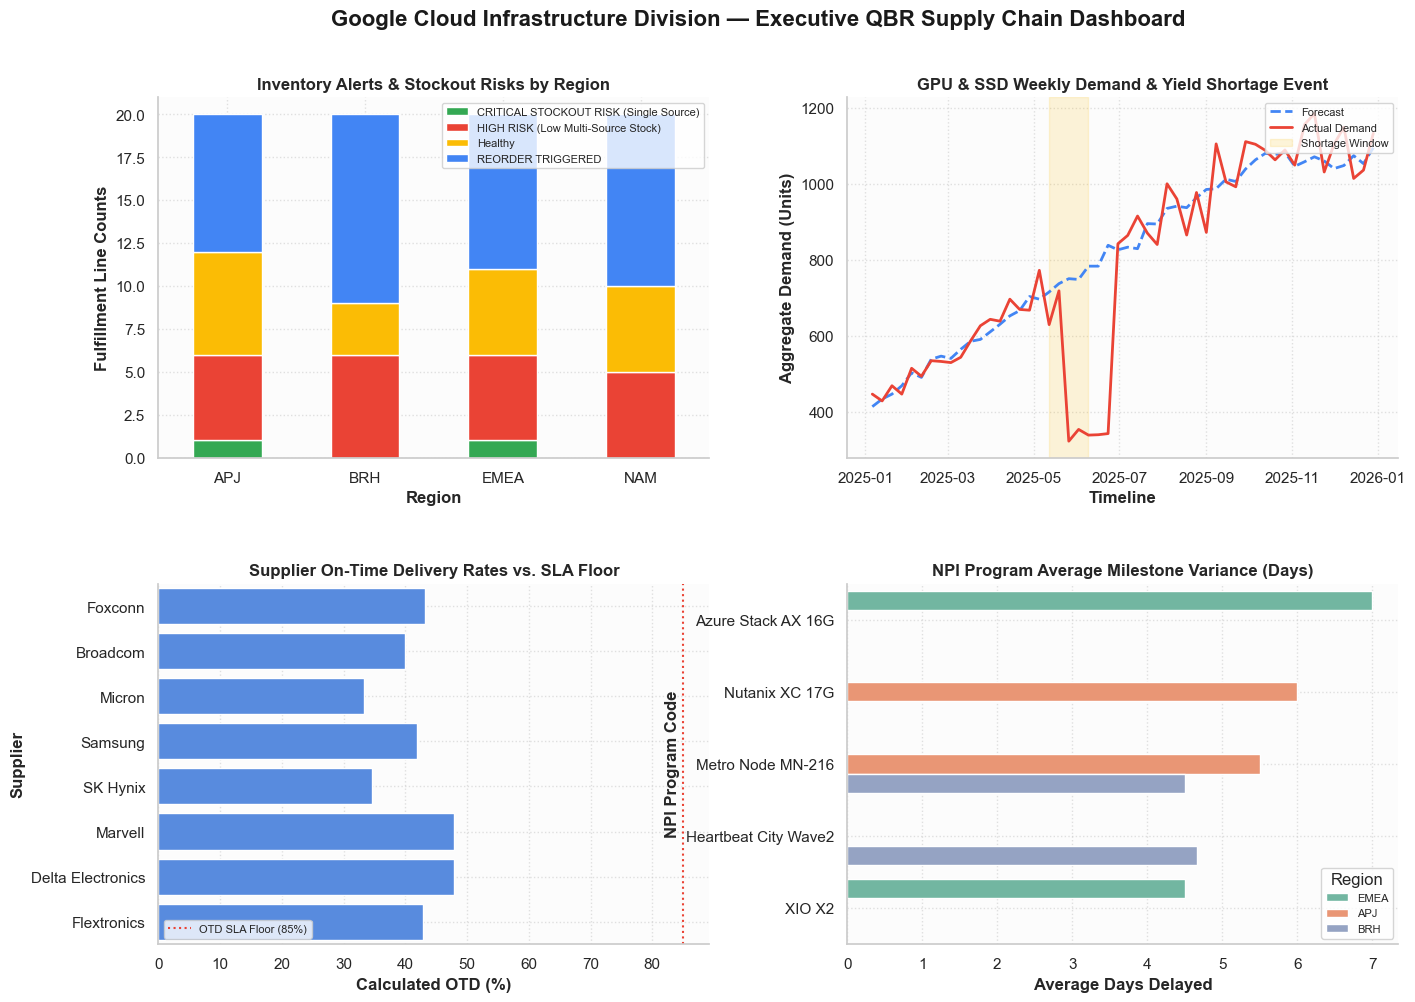

In [58]:
# Set up a professional 2x2 grid layout
fig, axes = plt.subplots(2, 2, figsize=(16, 11), gridspec_kw={'hspace': 0.35, 'wspace': 0.25})
fig.suptitle("Google Cloud Infrastructure Division — Executive QBR Supply Chain Dashboard", 
             fontsize=16, fontweight='bold', color='#1A1A1A', y=0.96)

# --- CHART 1: Regional Inventory Stockout Risk (Top Left) ---
alert_counts = inventory_risk_df.groupby(['Region', 'Fulfillment_Alert']).size().unstack(fill_value=0)
alert_counts.plot(kind='bar', stacked=True, ax=axes[0, 0], 
                  color=['#34A853', '#EA4335', '#FBBC05', '#4285F4'])
axes[0, 0].set_title("Inventory Alerts & Stockout Risks by Region", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Region", fontweight='bold')
axes[0, 0].set_ylabel("Fulfillment Line Counts", fontweight='bold')
axes[0, 0].legend(loc='upper right', frameon=True, fontsize=8)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)

# --- CHART 2: Demand Shock (Top Right) ---
axes[0, 1].plot(weekly_trend['Week'], weekly_trend['Forecast'], label='Forecast', color='#4285F4', linewidth=2, linestyle='--')
axes[0, 1].plot(weekly_trend['Week'], weekly_trend['Actual'], label='Actual Demand', color='#EA4335', linewidth=2)
axes[0, 1].axvspan(start_date, end_date, color='#FBBC05', alpha=0.15, label='Shortage Window')
axes[0, 1].set_title("GPU & SSD Weekly Demand & Yield Shortage Event", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Timeline", fontweight='bold')
axes[0, 1].set_ylabel("Aggregate Demand (Units)", fontweight='bold')
axes[0, 1].legend(loc='upper right', frameon=True, fontsize=8)

# --- CHART 3: Supplier On-Time Delivery % (Bottom Left) ---
top_suppliers = po_summary.sort_values(by='Total_POs_Placed', ascending=False).head(8)
sns.barplot(data=top_suppliers, x='OTD_Percentage', y='Supplier', ax=axes[1, 0], color='#4285F4')
axes[1, 0].axvline(x=85.0, color='#EA4335', linestyle=':', label='OTD SLA Floor (85%)')
axes[1, 0].set_title("Supplier On-Time Delivery Rates vs. SLA Floor", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Calculated OTD (%)", fontweight='bold')
axes[1, 0].set_ylabel("Supplier", fontweight='bold')
axes[1, 0].legend(loc='lower left', frameon=True, fontsize=8)

# --- CHART 4: Program Milestone Schedule Delays (Bottom Right) ---
npi_delays = npi_tracker[npi_tracker['Days_Variance'] > 0].groupby(['Program', 'Region']).agg(
    Avg_Delay=('Days_Variance', 'mean')
).reset_index().sort_values(by='Avg_Delay', ascending=False).head(6)

sns.barplot(data=npi_delays, x='Avg_Delay', y='Program', hue='Region', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title("NPI Program Average Milestone Variance (Days)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Average Days Delayed", fontweight='bold')
axes[1, 1].set_ylabel("NPI Program Code", fontweight='bold')
axes[1, 1].legend(title="Region", frameon=True, loc='lower right', fontsize=8)

# Polish spines for all axes
for row in axes:
    for ax in row:
        sns.despine(ax=ax)
        ax.set_facecolor('#FCFCFC')
        ax.grid(True, linestyle=':', alpha=0.6, color='#CCCCCC')

# Adjust layout and export the plot
plt.savefig('executive_qbr_supply_chain_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
